# K-Means Clustering: Poker Player Profiling

This notebook applies K-Means clustering to player-level poker features extracted from a sampled subset of the IRC Poker Dataset.

## Goals
- Load processed player-level features
- Standardize VPIP and PFR
- Select a reasonable number of clusters
- Fit a final K-Means model
- Visualize clusters and centroids
- Compare clustering results to a heuristic baseline using silhouette score

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

## Environment Setup

We mount Google Drive, define file paths, and set plotting defaults.

In [5]:
drive.mount('/content/drive')

PLAYER_STATS_PATH = '/content/drive/MyDrive/CS 4824 Group Project/data/processed/player_stats_sampled.csv'

sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a']
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Processed Player-Level Data

We load the player-level feature file created in the EDA notebook. Each row represents one player, along with their total hands played, VPIP, and PFR.

In [6]:
player_stats = pd.read_csv(PLAYER_STATS_PATH)
print(f'Loaded {len(player_stats):,} players')
player_stats.head()

Loaded 344 players


,player,total_hands,vpip_hands,pfr_hands,VPIP,PFR,heuristic_label
0,AROD,1336,763,497,57.110778,37.200599,LAG
1,Aesop,176,89,17,50.568182,9.659091,Fish
2,AlexPOgan,188,74,10,39.361702,5.319149,Fish
3,Apus,40,27,6,67.500000,15.000000,LAG
4,Arnie,148,75,22,50.675676,14.864865,Fish


## Define the Heuristic Baseline

For comparison, we assign each player to one of four traditional poker player types using fixed VPIP and PFR thresholds.

In [7]:
VPIP_THRESH = 25.0
PFR_THRESH = 15.0

def heuristic_label(row):
    tight = row['VPIP'] < VPIP_THRESH
    aggressive = row['PFR'] >= PFR_THRESH

    if tight and aggressive:
        return 'TAG'
    if not tight and aggressive:
        return 'LAG'
    if not tight and not aggressive:
        return 'Fish'
    return 'Rock'

player_stats['heuristic_label'] = player_stats.apply(heuristic_label, axis=1)
player_stats['heuristic_label'].value_counts()

,count
heuristic_label,
Fish,216
LAG,96
Rock,31
TAG,1


## Preparing Features for Clustering

K-Means uses Euclidean distance, so we standardize VPIP and PFR before clustering to ensure both features contribute equally.

In [8]:
features = player_stats[['VPIP', 'PFR']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

## Choose the Number of Clusters

We evaluate values of \(K\) from 2 to 8 using:
- inertia (elbow method)
- silhouette score

This helps us understand the clustering structure before fitting the final model.

In [9]:
K_RANGE = range(2, 9)
inertias = []
sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

best_k = list(K_RANGE)[np.argmax(sil_scores)]
print(f'Best K by silhouette: {best_k} (score = {max(sil_scores):.4f})')

Best K by silhouette: 2 (score = 0.5218)


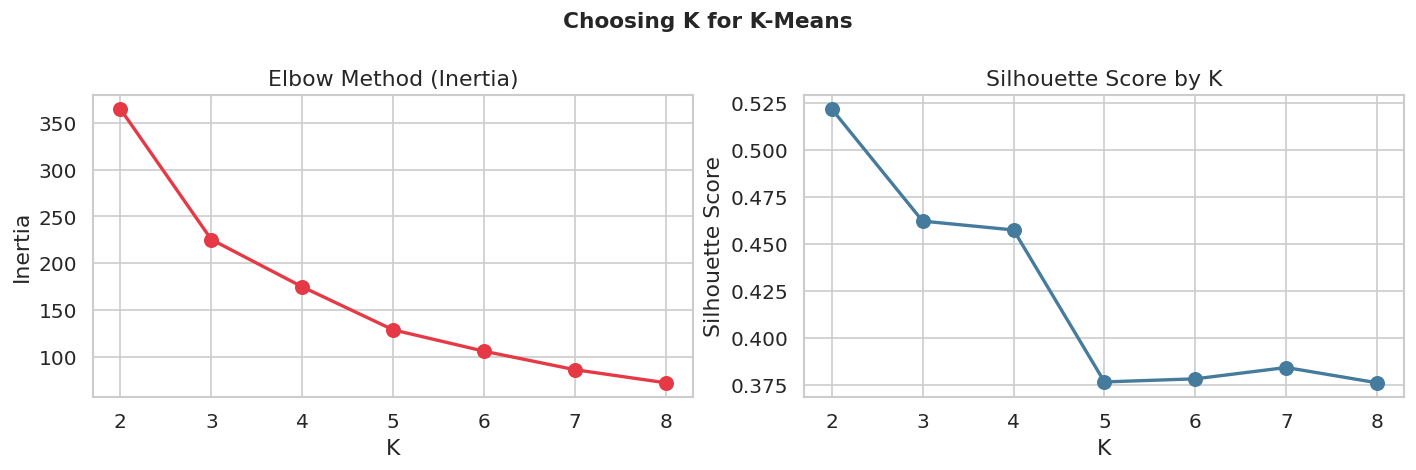

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_RANGE), inertias, 'o-', color=PALETTE[0], linewidth=2, markersize=8)
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(K_RANGE))

axes[1].plot(list(K_RANGE), sil_scores, 'o-', color=PALETTE[1], linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score by K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_RANGE))

plt.suptitle('Choosing K for K-Means', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Fit the Final K-Means Model

For comparison with the heuristic baseline, we use \(K = 4\), corresponding to the four traditional poker player types.

In [11]:
FINAL_K = 4

km_final = KMeans(n_clusters=FINAL_K, n_init=20, random_state=RANDOM_STATE)
player_stats['cluster'] = km_final.fit_predict(X_scaled)

final_sil = silhouette_score(X_scaled, player_stats['cluster'])
print(f'K-Means (K={FINAL_K}) Silhouette Score: {final_sil:.4f}')

K-Means (K=4) Silhouette Score: 0.4595


## Inspect Cluster Centroids

We transform the centroids back to the original VPIP/PFR scale to make them easier to interpret.

In [12]:
centroids_orig = scaler.inverse_transform(km_final.cluster_centers_)
centroid_df = pd.DataFrame(centroids_orig, columns=['VPIP_centroid', 'PFR_centroid'])
centroid_df.index.name = 'Cluster'
centroid_df.round(2)

,VPIP_centroid,PFR_centroid
Cluster,,
0,63.81,9.06
1,34.57,8.38
2,65.27,31.89
3,82.93,69.33


## Visualize the Clusters

We plot the cluster assignments in VPIP/PFR space and overlay the centroid locations.

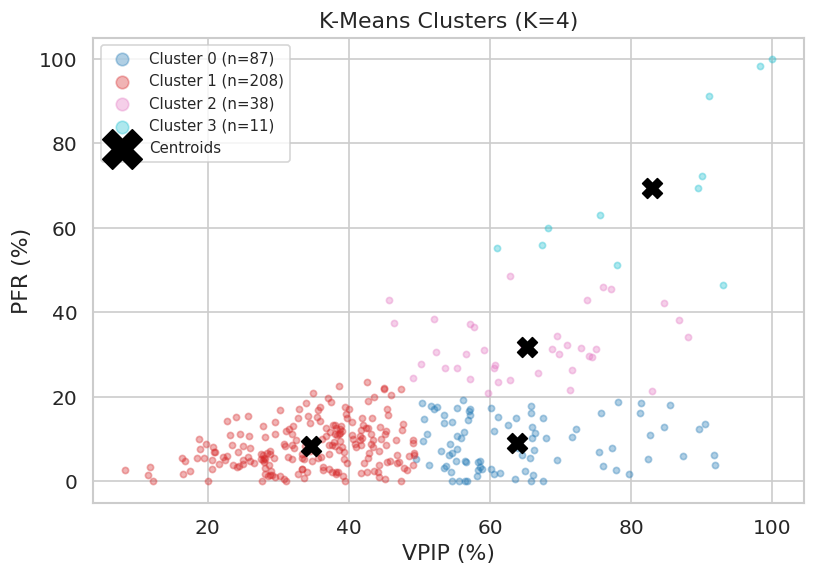

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
cmap = plt.get_cmap('tab10', FINAL_K)

for cluster_id in range(FINAL_K):
    mask = player_stats['cluster'] == cluster_id
    ax.scatter(
        player_stats.loc[mask, 'VPIP'],
        player_stats.loc[mask, 'PFR'],
        label=f'Cluster {cluster_id} (n={mask.sum()})',
        alpha=0.35,
        s=14,
        color=cmap(cluster_id)
    )

ax.scatter(
    centroid_df['VPIP_centroid'],
    centroid_df['PFR_centroid'],
    marker='X',
    s=140,
    c='black',
    zorder=5,
    label='Centroids'
)

ax.set_xlabel('VPIP (%)')
ax.set_ylabel('PFR (%)')
ax.set_title(f'K-Means Clusters (K={FINAL_K})')
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.show()

## Silhouette Plot

This plot shows the silhouette coefficient of each point within its assigned cluster.

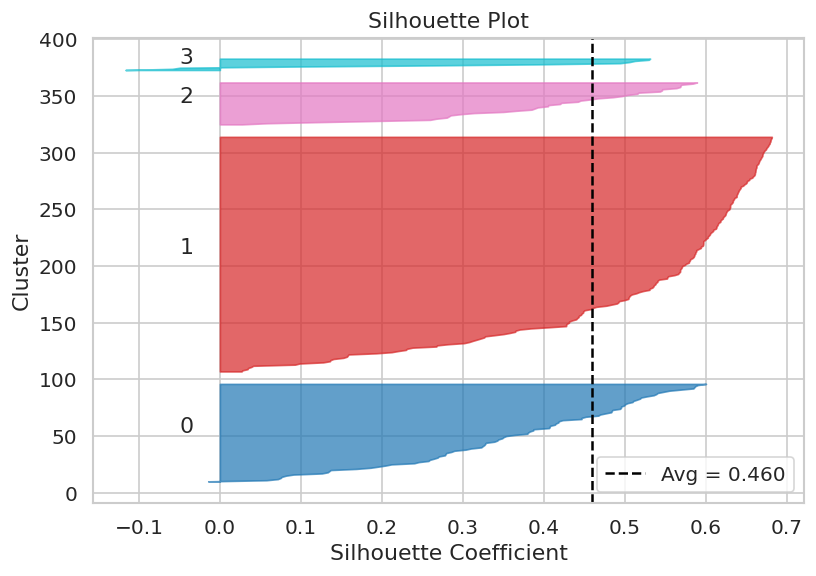

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
cmap = plt.get_cmap('tab10', FINAL_K)

sil_vals = silhouette_samples(X_scaled, player_stats['cluster'])
y_lower = 10

for cluster_id in range(FINAL_K):
    cluster_sil = np.sort(sil_vals[player_stats['cluster'] == cluster_id])
    y_upper = y_lower + cluster_sil.shape[0]

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_sil,
        facecolor=cmap(cluster_id),
        edgecolor=cmap(cluster_id),
        alpha=0.7
    )
    ax.text(-0.05, y_lower + 0.5 * cluster_sil.shape[0], str(cluster_id))
    y_lower = y_upper + 10

ax.axvline(final_sil, color='black', linestyle='--', label=f'Avg = {final_sil:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot')
ax.legend()
plt.tight_layout()
plt.show()

## Compare K-Means to the Heuristic Baseline

We compute the silhouette score for the heuristic labels and compare it to the score produced by K-Means.

In [15]:
label_map = {'TAG': 0, 'LAG': 1, 'Fish': 2, 'Rock': 3}
heuristic_sil = silhouette_score(X_scaled, player_stats['heuristic_label'].map(label_map))

print('=' * 45)
print(f'  Heuristic Silhouette Score : {heuristic_sil:.4f}')
print(f'  K-Means   Silhouette Score : {final_sil:.4f}  (K={FINAL_K})')
print('=' * 45)

if final_sil > heuristic_sil:
    print('  → K-Means produces tighter, better-separated clusters.')
else:
    print('  → Heuristic groupings are comparably well-separated.')

  Heuristic Silhouette Score : 0.0990
  K-Means   Silhouette Score : 0.4595  (K=4)
  → K-Means produces tighter, better-separated clusters.


## Summary

In this notebook, we:
- loaded processed player-level VPIP and PFR features
- standardized the features for clustering
- evaluated multiple values of \(K\)
- fit a final K-Means model with \(K=4\)
- visualized clusters and centroids
- compared K-Means against a heuristic baseline using silhouette score

These results support the use of K-Means as a data-driven alternative to fixed-rule poker player profiling.